In [ ]:
# pip install statsforecast

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsforecast import StatsForecast
from statsforecast.models import AutoETS, Naive
from sklearn.metrics import mean_absolute_error, mean_squared_error


In [ ]:
# Load the processed dataset
df = pd.read_csv("../data/processed/processed_data.csv")
df["Date"] = pd.to_datetime(df["Date"])

# Rename columns to standard statsforecast format
df_new = df.rename(columns={"Store": "store", "Dept": "dept", "Date": "ds", "Weekly_Sales": "y"}).copy()
df_new["unique_id"] = df_new["store"].astype(str) + "_" + df_new["dept"].astype(str)
df_new = df_new[["unique_id", "ds", "y"]]

print(f"Dataset shape: {df_new.shape}")
print(f"Total unique store-department series: {df_new['unique_id'].nunique()}")


In [ ]:
SPLIT_DATE = "2012-03-01"
FREQ = "W-FRI"
SEASON_LENGTH = 52

# Split into train and validation sets
train_raw = df_new[df_new.ds <= SPLIT_DATE].copy()
valid_raw = df_new[df_new.ds > SPLIT_DATE].copy()

total_train_weeks = train_raw["ds"].nunique()
print(f"Expected weeks in training set: {total_train_weeks}")


In [ ]:
# series_diagnostics = []
# grouped = list(train_raw.groupby("unique_id"))
# total_series = len(grouped)

# print(f"Analyzing {total_series} series for quality metrics...")

# for i, (uid, group) in enumerate(grouped):
#     if i % 500 == 0 and i > 0:
#         print(f"Processed {i} / {total_series} series...")
        
#     y_vals = group["y"].values
#     n_obs = len(y_vals)
    
#     # 1. Missing weeks check
#     missing_weeks = total_train_weeks - n_obs
    
#     # 2. Zero/negative sales check (sales <= 0.1)
#     zero_neg_count = np.sum(y_vals <= 0.1)
#     zero_neg_pct = zero_neg_count / n_obs if n_obs > 0 else 0
    
#     # 3. Stationarity check using ADF test
#     is_stationary = False
#     p_value = 1.0
#     if n_obs > 10 and np.var(y_vals) > 0.01:
#         try:
#             adf_result = adfuller(y_vals, maxlag=12, autolag='AIC')
#             p_value = adf_result[1]
#             is_stationary = (p_value < 0.05) # Stationary if p-value is less than 0.05
#         except Exception:
#             pass
            
#     series_diagnostics.append({
#         "unique_id": uid,
#         "n_obs": n_obs,
#         "missing_weeks": missing_weeks,
#         "zero_neg_pct": zero_neg_pct,
#         "adf_p_value": p_value,
#         "is_stationary": is_stationary
#     })

# df_diag = pd.DataFrame(series_diagnostics)
# print("Diagnostics complete!")


In [ ]:
# # Filtering Thresholds (Adjustable)
# MIN_WEEKS = 100               # Minimum expected training weeks out of 108
# MAX_ZERO_PCT = 0.05           # Maximum zero/negative sales percentage allowed (5%)

# # Create Boolean masks for bad series
# too_many_missing = df_diag["n_obs"] < MIN_WEEKS
# too_many_zeros = df_diag["zero_neg_pct"] > MAX_ZERO_PCT
# not_stationary = ~df_diag["is_stationary"]

# # Extract lists of IDs failing each check
# bad_missing_ids = df_diag[too_many_missing]["unique_id"].tolist()
# bad_zeros_ids = df_diag[too_many_zeros & ~too_many_missing]["unique_id"].tolist()
# bad_non_stationary_ids = df_diag[not_stationary & ~too_many_missing & ~too_many_zeros]["unique_id"].tolist()

# # Classify good and bad unique IDs
# bad_ids = set(df_diag[too_many_missing | too_many_zeros | not_stationary]["unique_id"])
# good_ids = set(df_diag["unique_id"]) - bad_ids

# print("--- Filtering Summary ---")
# print(f"Total Unique Series Evaluated: {total_series}")
# print(f"1. Filtered due to missing weeks (< {MIN_WEEKS}): {len(bad_missing_ids)}")
# print(f"2. Filtered due to zero/negative sales (> {MAX_ZERO_PCT*100}%): {len(bad_zeros_ids)}")
# print(f"3. Filtered due to non-stationarity (ADF p-value >= 0.05): {len(bad_non_stationary_ids)}")
# print(f"--------------------------------------------------")
# print(f"Total Series Removed (Bad Performers): {len(bad_ids)}")
# print(f"Total Series Kept (Good Performers): {len(good_ids)}")


In [ ]:
# # Visualizing quality differences
# fig, axes = plt.subplots(2, 2, figsize=(15, 8))

# # 1. Too many missing weeks
# if len(bad_missing_ids) > 0:
#     sample_missing = train_raw[train_raw["unique_id"] == bad_missing_ids[0]]
#     axes[0, 0].plot(sample_missing["ds"], sample_missing["y"], color="orange")
#     axes[0, 0].set_title(f"Missing Weeks Example: {bad_missing_ids[0]} (Obs: {len(sample_missing)})")

# # 2. Too many zeros
# if len(bad_zeros_ids) > 0:
#     sample_zeros = train_raw[train_raw["unique_id"] == bad_zeros_ids[0]]
#     axes[0, 1].plot(sample_zeros["ds"], sample_zeros["y"], color="red")
#     axes[0, 1].set_title(f"Zero Sales Example: {bad_zeros_ids[0]}")

# # 3. Non-Stationary
# if len(bad_non_stationary_ids) > 0:
#     sample_non_stat = train_raw[train_raw["unique_id"] == bad_non_stationary_ids[0]]
#     axes[1, 0].plot(sample_non_stat["ds"], sample_non_stat["y"], color="purple")
#     axes[1, 0].set_title(f"Non-Stationary Example: {bad_non_stationary_ids[0]}")

# # 4. Good series
# if len(good_ids) > 0:
#     sample_good = train_raw[train_raw["unique_id"] == list(good_ids)[0]]
#     axes[1, 1].plot(sample_good["ds"], sample_good["y"], color="green")
#     axes[1, 1].set_title(f"Good Series Example: {list(good_ids)[0]}")

# plt.tight_layout()
# plt.show()


In [ ]:
# # Keep only the good series
# train_clean = train_raw[train_raw["unique_id"].isin(good_ids)].copy()
# valid_clean = valid_raw[valid_raw["unique_id"].isin(good_ids)].copy()

# # Fill minor gaps for good series (reindex with all training dates and fill)
# all_train_dates = pd.date_range(start=train_clean["ds"].min(), end=train_clean["ds"].max(), freq=FREQ)
# full_train_index = pd.MultiIndex.from_product([list(good_ids), all_train_dates], names=["unique_id", "ds"])

# train_clean = train_clean.set_index(["unique_id", "ds"]).reindex(full_train_index).reset_index()
# train_clean["y"] = train_clean.groupby("unique_id")["y"].transform(lambda s: s.ffill().bfill())

# # Align validation set
# valid_clean = valid_clean[valid_clean["unique_id"].isin(good_ids)].copy()

# print(f"Cleaned train set shape: {train_clean.shape}")
# print(f"Cleaned validation set shape: {valid_clean.shape}")


In [ ]:
good_series_data = []
repaired_series_data = []
beyond_repair_ids = []

# Total expected training weeks
all_train_dates = pd.date_range(start=train_raw["ds"].min(), end=train_raw["ds"].max(), freq=FREQ, name="ds")

for uid, group in train_raw.groupby("unique_id"):
    y_vals = group["y"].values
    n_obs = len(y_vals)
    variance = np.var(y_vals) if n_obs > 0 else 0
    zero_neg_pct = np.sum(y_vals <= 0) / n_obs if n_obs > 0 else 1.0
    
    # 1. Beyond Repair Check
    if n_obs < 56:
        beyond_repair_ids.append((uid, "Too few data points (<56 weeks)"))
        continue
    elif variance < 0.01:
        beyond_repair_ids.append((uid, "Zero/Constant Variance"))
        continue
    elif zero_neg_pct > 0.80:
        beyond_repair_ids.append((uid, "Mostly Inactive/Sparse (>80% zeros)"))
        continue
        
    missing_weeks = total_train_weeks - n_obs
    has_zeros = np.any(y_vals <= 0)
    
    p_value = 1.0
    try:
        adf_result = adfuller(y_vals, maxlag=12, autolag='AIC')
        p_value = adf_result[1]
    except Exception:
        pass
    is_stationary = (p_value < 0.05)
    
    # Separate Good vs Repairable
    if missing_weeks == 0 and not has_zeros and is_stationary:
        # Keep only required columns
        good_series_data.append(group[["unique_id", "ds", "y"]])
    else:
        # Reindex with named datetime index
        repaired_group = group.set_index("ds").reindex(all_train_dates).reset_index()
        repaired_group["unique_id"] = uid
        
        # Replace zero or negative values with NaN
        repaired_group["y"] = repaired_group["y"].apply(lambda x: np.nan if x <= 0 else x)
        
        # Interpolate missing values and zero values
        repaired_group["y"] = repaired_group["y"].interpolate(method="linear").ffill().bfill()
        
        # Clip values to a small positive floor for AutoETS
        repaired_group["y"] = repaired_group["y"].clip(lower=0.1)
        
        # Explicitly keep ONLY the 3 columns expected by StatsForecast
        repaired_group = repaired_group[["unique_id", "ds", "y"]]
        repaired_series_data.append(repaired_group)


In [23]:
df_good = pd.concat(good_series_data) if len(good_series_data) > 0 else pd.DataFrame(columns=["unique_id", "ds", "y"])
df_repaired = pd.concat(repaired_series_data) if len(repaired_series_data) > 0 else pd.DataFrame(columns=["unique_id", "ds", "y"])

train_clean = pd.concat([df_good, df_repaired]).reset_index(drop=True)
repaired_uids = df_repaired["unique_id"].unique() if not df_repaired.empty else []
good_uids = df_good["unique_id"].unique() if not df_good.empty else []
df_beyond = pd.DataFrame(beyond_repair_ids, columns=["unique_id", "reason"])

print("--- Data Repair & Filtering Report ---")
print(f"Original Series:                 {train_raw['unique_id'].nunique()}")
print(f"1. Kept without changes (Good):  {len(good_uids)}")
print(f"2. Repaired & Saved:             {len(repaired_uids)}")
print(f"3. Discarded (Beyond Repair):    {len(df_beyond)}")
print(f"--------------------------------------")
print(f"Total Series Ready for Training: {train_clean['unique_id'].nunique()}")


--- Data Repair & Filtering Report ---
Original Series:                 3310
1. Kept without changes (Good):  1878
2. Repaired & Saved:             1058
3. Discarded (Beyond Repair):    374
--------------------------------------
Total Series Ready for Training: 2936


In [24]:
valid_clean = valid_raw[valid_raw["unique_id"].isin(train_clean["unique_id"].unique())].copy()


In [ ]:
sf = StatsForecast(
    models=[AutoETS(season_length=SEASON_LENGTH, model="AAA")],
    freq=FREQ,
    fallback_model=Naive(),
    n_jobs=-1
)

print("Training AutoETS on the cleaned good series...")
sf.fit(train_clean)
print("Training completed successfully!")


Training AutoETS on the cleaned good series...
Training completed successfully!


In [26]:
h = valid_clean["ds"].nunique()
print(f"Forecasting horizon: {h} weeks")

forecast = sf.predict(h=h)
print(forecast.head())


Forecasting horizon: 35 weeks
  unique_id         ds       AutoETS
0      10_1 2012-03-02  33360.356535
1      10_1 2012-03-09  33248.847504
2      10_1 2012-03-16  35001.745917
3      10_1 2012-03-23  48414.304775
4      10_1 2012-03-30  91617.032313


In [ ]:
results_clean = valid_clean.merge(forecast, on=["unique_id", "ds"])

mae = np.mean(np.abs(results_clean["y"] - results_clean["AutoETS"]))
rmse = np.sqrt(np.mean((results_clean["y"] - results_clean["AutoETS"])**2))
wmape = (np.abs(results_clean["y"] - results_clean["AutoETS"]).sum() / np.abs(results_clean["y"]).sum()) * 100
accuracy = 100 - wmape

print("--- Cleaned Model Evaluation ---")
print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"WMAPE: {wmape:.2f}%")
print(f"Overall Accuracy: {accuracy:.2f}%")


--- Cleaned Model Evaluation ---
MAE:  1774.69
RMSE: 3564.23
WMAPE: 10.91%
Overall Accuracy: 89.09%


In [31]:
# 1. Define a helper function to calculate wMAPE for each series
def calculate_series_wmape(group):
    actual = group['y']
    predicted = group['AutoETS']  # Using the AutoETS predictions
    
    # Avoid division by zero if sales are zero/0.1
    if actual.sum() <= 5: 
        return np.nan
        
    return (np.abs(actual - predicted).sum() / actual.sum()) * 100

# 2. Group by unique_id and apply the wMAPE calculation
series_errors = results_clean.groupby('unique_id').apply(calculate_series_wmape).reset_index(name='wmape')

# 3. Sort by wmape in descending order
worst_series = series_errors.dropna().sort_values(by='wmape', ascending=False)

print("--- WORST PERFORMING STORE-DEPARTMENTS (Highest wMAPE) ---")
print(worst_series.head(15).to_string(index=False))


--- WORST PERFORMING STORE-DEPARTMENTS (Highest wMAPE) ---
unique_id        wmape
     5_59 11714.280558
    43_28  4575.850724
     3_59  3095.575086
    35_80  3033.485660
    43_59  2079.685405
    33_25  1340.184306
    35_59  1278.777558
    16_59  1273.765877
     7_59  1216.364689
    10_59   739.693220
    34_51   653.401045
    22_94   605.750837
    21_94   585.145238
    30_17   580.172016
    35_54   512.160297


In [32]:
worst_series

,unique_id,wmape
2641,5_59,11714.280558
2377,43_28,4575.850724
2158,3_59,3095.575086
1892,35_80,3033.485660
2387,43_59,2079.685405
...,...,...
1586,31_13,2.824403
220,13_2,2.722464
2314,41_95,2.673334
1684,32_40,2.660734


In [37]:
worst_series[worst_series["wmape"]>30]

,unique_id,wmape
2641,5_59,11714.280558
2377,43_28,4575.850724
2158,3_59,3095.575086
1892,35_80,3033.485660
2387,43_59,2079.685405
...,...,...
1908,36_10,30.244457
2290,41_56,30.239353
1014,23_52,30.155727
2224,40_60,30.114518


In [36]:
worst_series[worst_series["wmape"]<30]

,unique_id,wmape
668,19_55,29.898186
2085,39_5,29.860559
629,19_11,29.813655
1476,2_24,29.635411
256,13_56,29.586093
...,...,...
1586,31_13,2.824403
220,13_2,2.722464
2314,41_95,2.673334
1684,32_40,2.660734


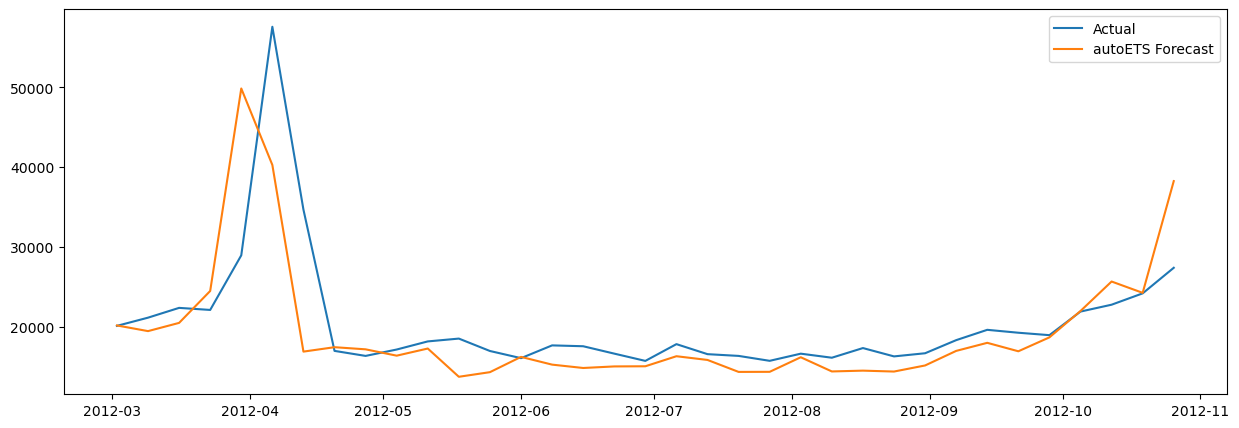

In [42]:
sample = "1_1"

actual = results_clean[
    results_clean["unique_id"] == sample
]

plt.figure(figsize=(15,5))

plt.plot(
    actual["ds"],
    actual["y"],
    label="Actual"
)

plt.plot(
    actual["ds"],
    actual["AutoETS"],
    label="autoETS Forecast"
)

plt.legend()

plt.show()

In [41]:
actual.shape

(35, 4)